In [3]:
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from scipy.io import loadmat
from pathlib import Path

In [4]:
# ------------------------------------------------------------------
# Load ACDC fieldmap data (Bay 5 Haotian processed fieldmap)
# ------------------------------------------------------------------
ACDC_fieldmap_data = np.load('ACDC_fieldmap_data/fieldmap_bay5.npz')
ACDC_fieldmap_haotian = ACDC_fieldmap_data['fieldmap_Hz']       # basis fieldmaps
fieldmap_coords_haotian = ACDC_fieldmap_data['coords_xyz']       # spatial coordinate grid
fieldmap_mask_haotian = ACDC_fieldmap_data['data_mask']          # valid-data mask
print(
    'Loaded ACDC fieldmap data (haotian): \nACDC_fieldmap_haotian: {}, fieldmap_coords_haotian: {}, fieldmap_mask_haotian: {}'.format(ACDC_fieldmap_haotian.shape, fieldmap_coords_haotian.shape, fieldmap_mask_haotian.shape)
)

Loaded ACDC fieldmap data (haotian): 
ACDC_fieldmap_haotian: (31, 112, 112, 112), fieldmap_coords_haotian: (3, 112, 112, 112), fieldmap_mask_haotian: (112, 112, 112)


In [5]:
ACDC_fieldmap_data_jason = loadmat('ACDC_fieldmap_data/coil_basis_Rev_D_3T_Bay_5_April_2026 1.mat')
print(ACDC_fieldmap_data_jason['coil'][0,0][0].shape)
print(ACDC_fieldmap_data_jason['coil'][0,0][1].shape)
print(ACDC_fieldmap_data_jason['coil'][0,0][2].shape)
print(ACDC_fieldmap_data_jason['coil'][0,0][3].shape)
print(ACDC_fieldmap_data_jason['coil'][0,0][4].shape)
ACDC_fieldmap_jason = ACDC_fieldmap_data_jason['coil'][0,0][0]  # shape (n_x, n_y, n_z, n_coils)
fieldmap_mask_jason = ACDC_fieldmap_data_jason['coil'][0,0][4]  # shape (n_x, n_y, n_z)

ACDC_fieldmap_jason = rearrange(ACDC_fieldmap_jason, 'x y z c -> c x y z')  # shape (n_coils, n_x, n_y, n_z)

fieldmap_coord_data_jason = loadmat('ACDC_fieldmap_data/coords.mat')
fieldmap_coords_jason = np.stack((
    fieldmap_coord_data_jason['XX'], fieldmap_coord_data_jason['YY'], fieldmap_coord_data_jason['ZZ']), axis=0)  # shape (3, n_x, n_y, n_z)
print(
    'Loaded ACDC fieldmap data (Jason): \nACDC_fieldmap_jason: {}, fieldmap_coords_jason: {}, fieldmap_mask_jason: {}'.format(ACDC_fieldmap_jason.shape, fieldmap_coords_jason.shape, fieldmap_mask_jason.shape)
)

(112, 112, 112, 32)
(1,)
(1,)
(112, 112, 112)
(112, 112, 112)
Loaded ACDC fieldmap data (Jason): 
ACDC_fieldmap_jason: (32, 112, 112, 112), fieldmap_coords_jason: (3, 112, 112, 112), fieldmap_mask_jason: (112, 112, 112)


In [6]:
print(ACDC_fieldmap_jason.max(), ACDC_fieldmap_jason.min(), ACDC_fieldmap_jason.mean())
print(ACDC_fieldmap_haotian.max(), ACDC_fieldmap_haotian.min(), ACDC_fieldmap_haotian.mean())

896.2408854166666 -987.6778564453125 -0.7716871211045778
899.8798479582034 -801.4958061302492 -0.687146460484189


C:\Users\bughh\AppData\Local\Temp\ipykernel_51380\2124442131.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


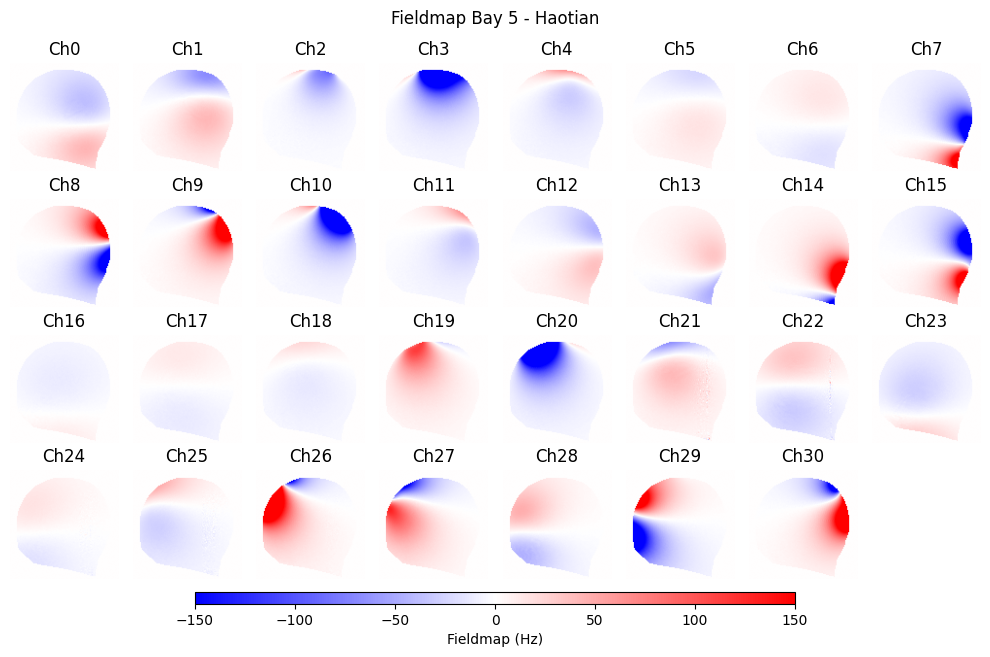

C:\Users\bughh\AppData\Local\Temp\ipykernel_51380\2124442131.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


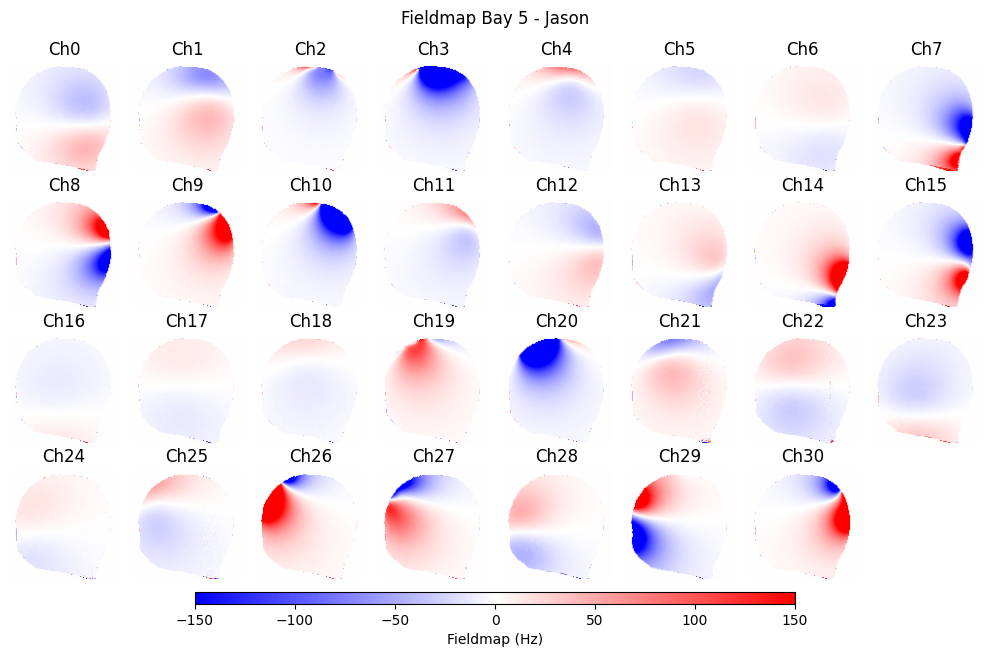

In [9]:
plt.figure(figsize=(10,6))
for i in range(31):
    plt.subplot(4, 8, i+1)
    plt.imshow(ACDC_fieldmap_haotian[i,:,64,::-1].T, cmap='bwr')
    plt.xticks([])
    plt.clim(-150,150)
    plt.title(f"Ch{i}")
    plt.axis('off')
cbar_ax = plt.gcf().add_axes([0.2, -0.01, 0.6, 0.02])  # [left, bottom, width, height]
plt.colorbar(cax=cbar_ax, orientation='horizontal', label='Fieldmap (Hz)')
plt.suptitle("Fieldmap Bay 5 - Haotian")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
for i in range(31):
    plt.subplot(4, 8, i+1)
    plt.imshow(ACDC_fieldmap_jason[i,:,64,::-1].T, cmap='bwr')
    plt.xticks([])
    plt.clim(-150,150)
    plt.title(f"Ch{i}")
    plt.axis('off')
cbar_ax = plt.gcf().add_axes([0.2, -0.01, 0.6, 0.02])  # [left, bottom, width, height]
plt.colorbar(cax=cbar_ax, orientation='horizontal', label='Fieldmap (Hz)')
plt.suptitle("Fieldmap Bay 5 - Jason")
plt.tight_layout()

C:\Users\bughh\AppData\Local\Temp\ipykernel_51380\921644279.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


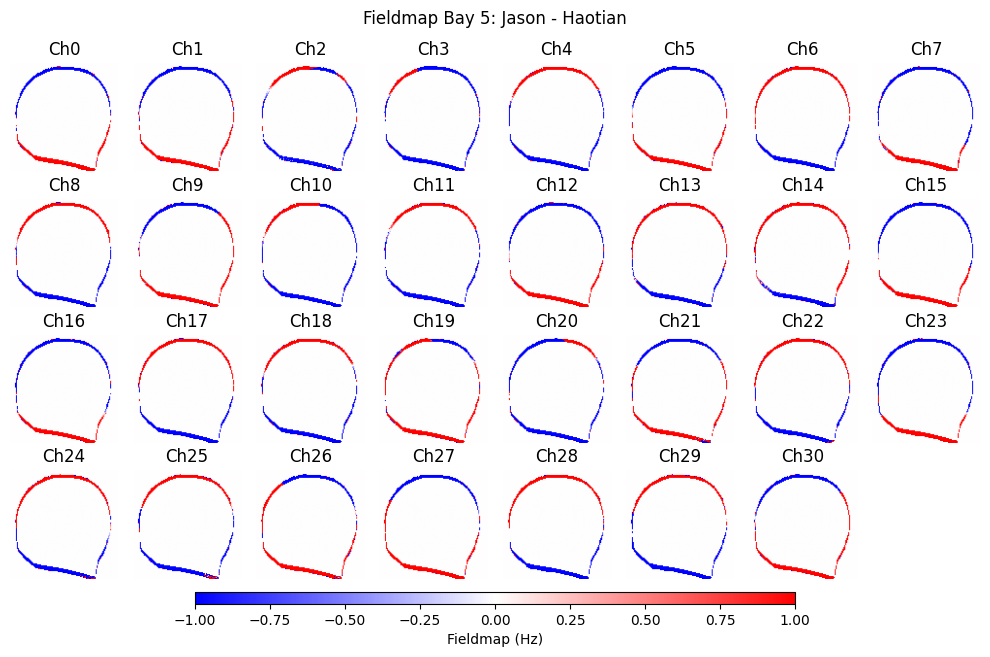

In [10]:
plt.figure(figsize=(10,6))
for i in range(31):
    plt.subplot(4, 8, i+1)
    plt.imshow((ACDC_fieldmap_jason[i,:,64,::-1].T - ACDC_fieldmap_haotian[i,:,64,::-1].T), cmap='bwr')
    plt.xticks([])
    plt.clim(-1,1)
    plt.title(f"Ch{i}")
    plt.axis('off')
cbar_ax = plt.gcf().add_axes([0.2, -0.01, 0.6, 0.02])  # [left, bottom, width, height]
plt.colorbar(cax=cbar_ax, orientation='horizontal', label='Fieldmap (Hz)')
plt.suptitle("Fieldmap Bay 5: Jason - Haotian")
plt.tight_layout()